In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [128]:
sns.set_style("darkgrid")

In [129]:
from sklearn.preprocessing import PowerTransformer

In [130]:
df = pd.read_csv("crop_recommendation_dataset.csv")


Missing Before:
 N              169
P                5
K                5
temperature      0
humidity         0
ph               0
rainfall         2
Soil_OC          0
label            0
dtype: int64

Missing After:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Soil_OC        0
label          0
dtype: int64


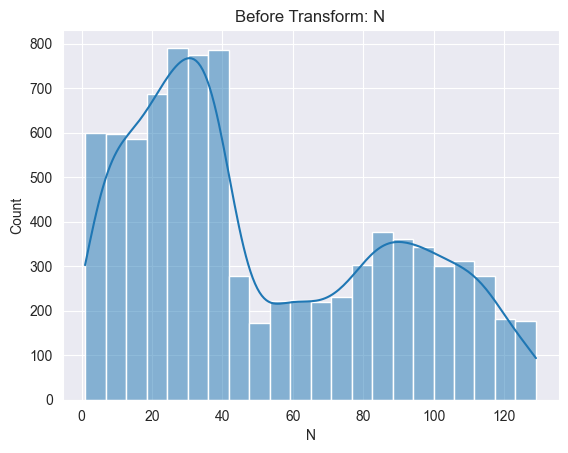

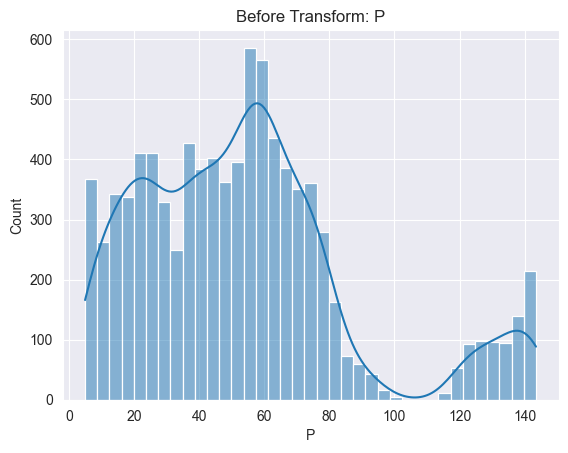

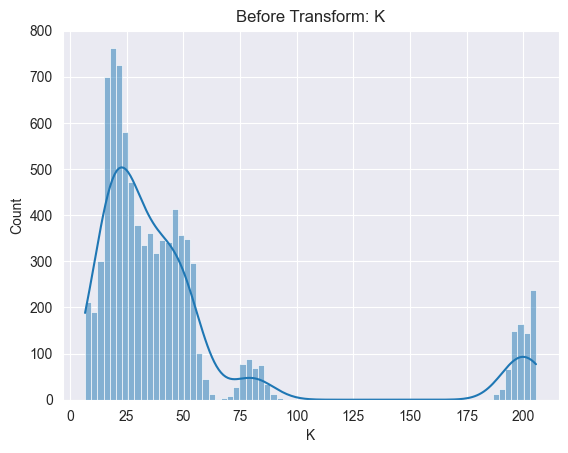

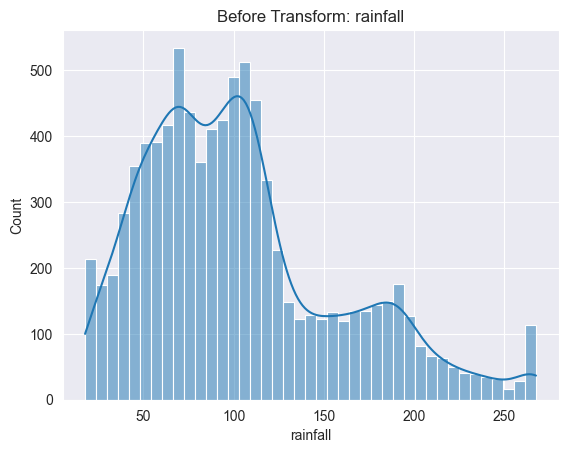

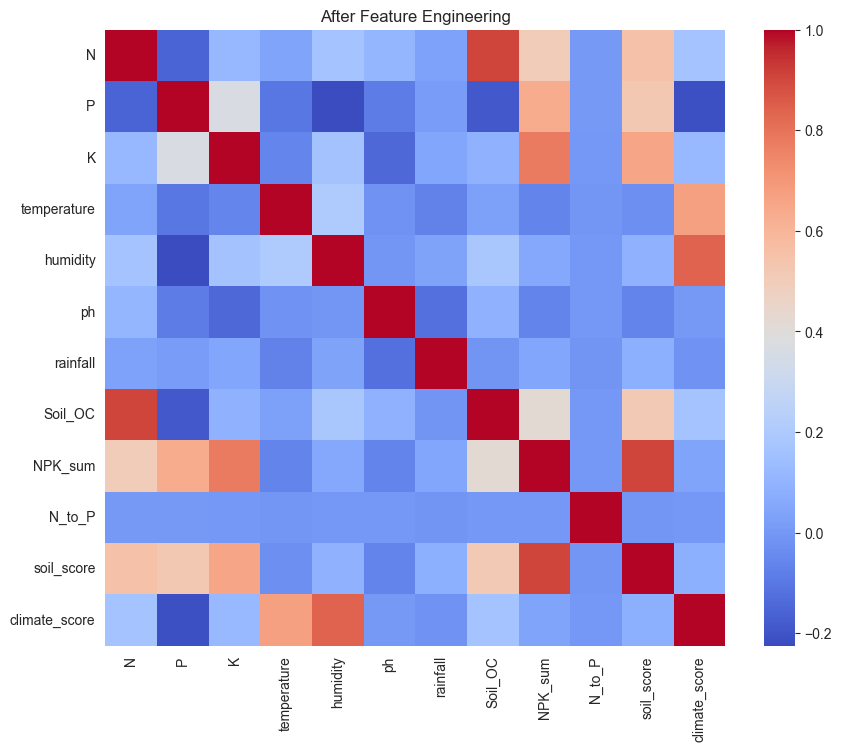

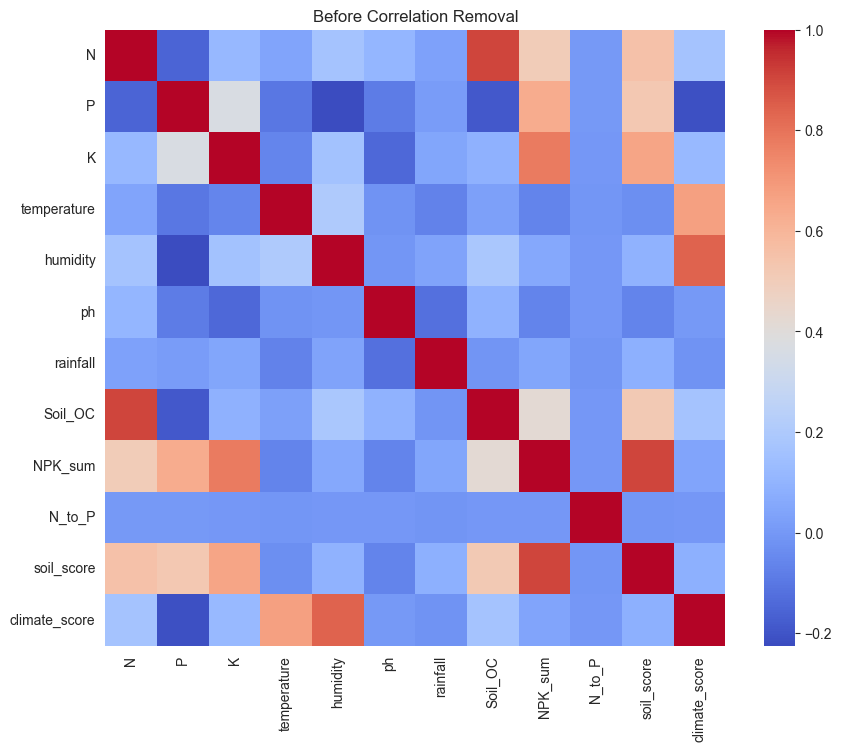

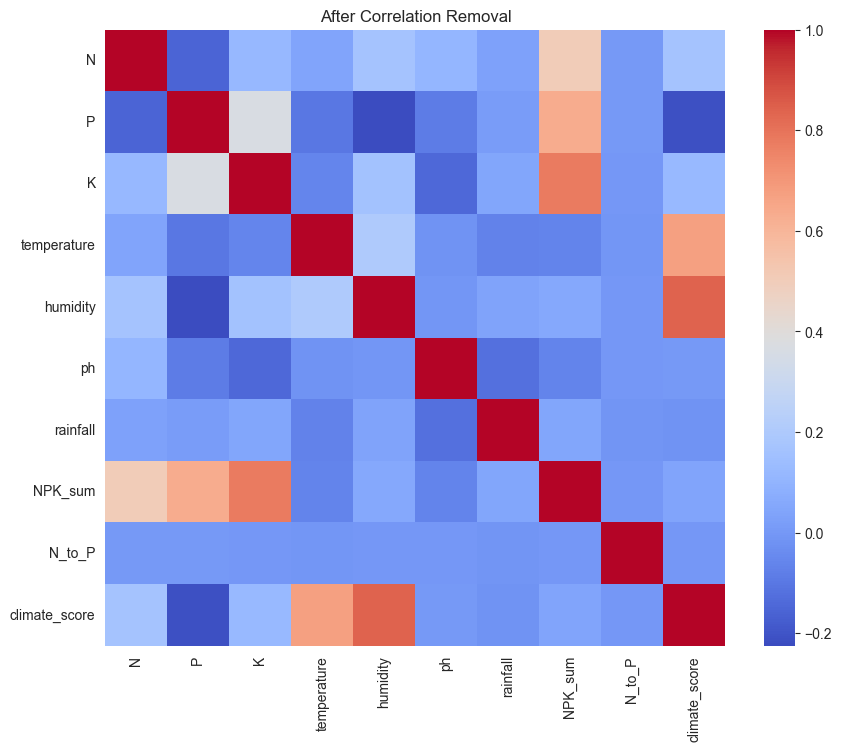

In [131]:
cols = ['N','P','K','rainfall','humidity']

for col in ['N','P','K','rainfall']:
    df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)
df['humidity'] = df['humidity'].clip(0, 100)
df['ph'] = df['ph'].clip(0, 14)

# ==============================
# 2. HANDLE MISSING VALUES
# ==============================

print("\nMissing Before:\n", df.isnull().sum())

df.fillna(df.median(numeric_only=True), inplace=True)

print("\nMissing After:\n", df.isnull().sum())



# ==============================
# 5. OUTLIER HANDLING
# ==============================

# BEFORE (Plotly boxplot)
for col in ['N','P','K','rainfall']:
    fig = px.box(df, y=col, title=f"Before Outlier Fix: {col}")
    fig.show()

# Capping
def cap_outliers(df, cols):
    for col in cols:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(lower, upper)
    return df

df = cap_outliers(df, ['N','P','K','rainfall'])

# AFTER
for col in ['N','P','K','rainfall']:
    fig = px.box(df, y=col, title=f"After Outlier Fix: {col}")
    fig.show()

# =============================
# 4. TRANSFORM DISTRIBUTIONS
# ==============================

for col in ['N','P','K','rainfall']:
    sns.histplot(df[col], kde=True)
    plt.title(f"Before Transform: {col}")
    plt.show()

# Log transform
for col in ['N','P','K','rainfall']:
    df[col] = np.log1p(df[col])

# Power transform
pt = PowerTransformer(method='yeo-johnson')
df[['N','P','K','rainfall']] = pt.fit_transform(df[['N','P','K','rainfall']])

# Plotly AFTER
for col in ['N','P','K','rainfall']:
    fig = px.histogram(df, x=col, nbins=50,
                       title=f"After Transform: {col}")
    fig.show()



# ==============================
# 6. FEATURE CONSTRUCTION
# ==============================

# Before relationships
fig = px.scatter_matrix(df,
                       dimensions=['N','P','K'],
                       title="Before Feature Engineering")
fig.show()

# New features
df['NPK_sum'] = df['N'] + df['P'] + df['K']
df['N_to_P'] = df['N'] / (df['P'] + 1e-5)
df['soil_score'] = df['Soil_OC'] * df['NPK_sum']
df['climate_score'] = df['temperature'] * df['humidity']

# After correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("After Feature Engineering")
plt.show()

# ==============================
# 7. REMOVE CORRELATED FEATURES
# ==============================

corr = df.corr(numeric_only=True)

# BEFORE heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Before Correlation Removal")
plt.show()

# Drop highly correlated
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

df = df.drop(columns=to_drop)

# AFTER
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("After Correlation Removal")
plt.show()


In [132]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier

# ==============================
# MAIN FUNCTION
# ==============================

def train_and_save_model(df, model_path="best_model.pkl"):

    # ------------------------------
    # Remove non-numeric columns
    # ------------------------------
    non_numeric = df.select_dtypes(exclude=['number']).columns
    non_numeric = [col for col in non_numeric if col != 'label']
    df = df.drop(columns=non_numeric)

    # ------------------------------
    # Encode label
    # ------------------------------
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['label'])

    X = df.drop(columns=['label'])
    y = df['label']

    # ------------------------------
    # Split (80/20 → then 80/20)
    # ------------------------------
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval
    )

    # ------------------------------
    # Models
    # ------------------------------
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(max_iter=2000))
        ]),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "XGBoost": XGBClassifier(eval_metric='mlogloss')
    }

    # ------------------------------
    # Parameter grids
    # ------------------------------
    param_grids = {
        "Logistic Regression": {"lr__C": [0.01, 0.1, 1]},
        "Decision Tree": {
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5]
        },
        "Random Forest": {
            "n_estimators": [100],
            "max_depth": [10, None]
        },
        "XGBoost": {
            "n_estimators": [100],
            "max_depth": [3, 6],
            "learning_rate": [0.1]
        }
    }

    # ------------------------------
    # Training + tuning
    # ------------------------------
    results = []

    for name, model in models.items():
        print(f"\nTraining {name}...")

        grid = GridSearchCV(
            model,
            param_grids[name],
            scoring='f1_weighted',
            cv=3,
            n_jobs=-1
        )

        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_

        y_val_pred = best_model.predict(X_val)
        f1 = f1_score(y_val, y_val_pred, average='weighted')

        print(f"{name} F1: {f1:.4f}")
        results.append([name, best_model, f1])

    # ------------------------------
    # Select best model
    # ------------------------------
    results_df = pd.DataFrame(results, columns=["Model", "Model_Obj", "F1"])
    best_row = results_df.sort_values(by="F1", ascending=False).iloc[0]

    best_model = best_row["Model_Obj"]
    print(f"\nBest Model: {best_row['Model']}")

    # ------------------------------
    # Retrain on full data (80%)
    # ------------------------------
    best_model.fit(X_trainval, y_trainval)

    # ------------------------------
    # Test evaluation
    # ------------------------------
    y_test_pred = best_model.predict(X_test)

    print("\nTest Performance:")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

    # ------------------------------
    # Save model + label encoder
    # ------------------------------
    with open(model_path, "wb") as f:
        pickle.dump((best_model, le, X.columns.tolist()), f)

    print(f"\nModel saved to {model_path}")

    return best_model, le, X.columns.tolist()

In [133]:
def load_and_predict(model_path, input_dict):

    import pandas as pd
    import pickle

    with open(model_path, "rb") as f:
        model, le, feature_cols = pickle.load(f)

    df = pd.DataFrame([input_dict])

    # Feature engineering (same as training)
    df['NPK_sum'] = df['N'] + df['P'] + df['K']
    df['N_to_P'] = df['N'] / (df['P'] + 1e-5)
    df['climate_score'] = df['temperature'] * df['humidity']

    # Align columns
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0

    df = df[feature_cols]

    # Predict
    prediction = model.predict(df)

    # 🔥 Convert number → label
    label = le.inverse_transform(prediction)

    return label[0]

In [ ]:
def load_and_predict_top3(model_path, input_dict):
    """
    Predict top 3 crop recommendations with confidence scores.
    
    Returns:
        list of tuples: [(crop_name, confidence_score), ...]
    """
    import pandas as pd
    import pickle
    import numpy as np

    with open(model_path, "rb") as f:
        model, le, feature_cols = pickle.load(f)

    df = pd.DataFrame([input_dict])

    # Feature engineering (same as training)
    df['NPK_sum'] = df['N'] + df['P'] + df['K']
    df['N_to_P'] = df['N'] / (df['P'] + 1e-5)
    df['climate_score'] = df['temperature'] * df['humidity']

    # Align columns
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0

    df = df[feature_cols]

    # Get probability predictions
    probabilities = model.predict_proba(df)[0]
    
    # Get top 3 indices
    top3_indices = np.argsort(probabilities)[-3:][::-1]
    
    # Convert to crop names and probabilities
    top3_crops = []
    for idx in top3_indices:
        crop_name = le.inverse_transform([idx])[0]
        confidence = probabilities[idx] * 100  # Convert to percentage
        top3_crops.append((crop_name, confidence))
    
    return top3_crops

In [ ]:
# Define sample input if not already defined
sample_input = {
    'N': 90,
    'P': 42,
    'K': 43,
    'temperature': 20.87,
    'humidity': 82.00,
    'ph': 6.50,
    'rainfall': 202.93,
    'Soil_OC': 1.2
}

# Get top 3 predictions
top3_predictions = load_and_predict_top3("best_model.pkl", sample_input)

print("\n" + "="*50)
print("TOP 3 CROP RECOMMENDATIONS")
print("="*50)
for i, (crop, confidence) in enumerate(top3_predictions, 1):
    print(f"{i}. {crop.upper():<20} - Confidence: {confidence:.2f}%")
print("="*50)

In [ ]:
def predict_with_comparison(model_path, input_dict, actual_crop=None):
    """
    Show both single prediction and top 3 recommendations.
    """
    # Single prediction
    single_pred = load_and_predict(model_path, input_dict)
    
    # Top 3 predictions
    top3_preds = load_and_predict_top3(model_path, input_dict)
    
    print("\n" + "="*60)
    print("CROP PREDICTION RESULTS")
    print("="*60)
    
    if actual_crop:
        print(f"Actual Crop:        {actual_crop.upper()}")
    
    print(f"\nTop Prediction:     {single_pred.upper()} (Best Match)")
    
    print("\nTop 3 Recommendations:")
    for i, (crop, confidence) in enumerate(top3_preds, 1):
        marker = "✓" if actual_crop and crop == actual_crop else " "
        print(f"  {marker} {i}. {crop.upper():<18} - {confidence:.2f}% confidence")
    
    print("="*60 + "\n")

In [ ]:
# Test with different crop conditions
print("\n" + "#"*60)
print("TESTING MULTIPLE SAMPLES FROM DATASET")
print("#"*60)

sample = df.sample(5, random_state=42)

for idx, (i, row) in enumerate(sample.iterrows(), 1):
    actual = row['label']
    input_data = row.drop('label').to_dict()
    
    print(f"\n{'='*60}")
    print(f"SAMPLE {idx}")
    predict_with_comparison("best_model.pkl", input_data, actual)

In [ ]:
# Example with custom agricultural conditions
custom_conditions = {
    'N': 70,           # Nitrogen
    'P': 50,           # Phosphorus  
    'K': 40,           # Potassium
    'temperature': 27, # Temperature in Celsius
    'humidity': 65,    # Humidity percentage
    'ph': 6.0,         # Soil pH
    'rainfall': 80,    # Rainfall in mm
    'Soil_OC': 1.0     # Soil Organic Carbon
}

print("\n" + "="*60)
print("CUSTOM SOIL & CLIMATE CONDITIONS")
print("="*60)
print("\nInput Conditions:")
for key, value in custom_conditions.items():
    print(f"  {key:<15}: {value}")

predict_with_comparison("best_model.pkl", custom_conditions)

In [ ]:
def get_crop_recommendations(N, P, K, temperature, humidity, ph, rainfall, Soil_OC):
    """
    Easy-to-use function to get crop recommendations.
    
    Parameters:
    -----------
    N : float - Nitrogen content
    P : float - Phosphorus content
    K : float - Potassium content
    temperature : float - Temperature in Celsius
    humidity : float - Humidity percentage
    ph : float - Soil pH level
    rainfall : float - Rainfall in mm
    Soil_OC : float - Soil Organic Carbon
    
    Returns:
    --------
    Top 3 crop recommendations with confidence scores
    """
    input_data = {
        'N': N,
        'P': P,
        'K': K,
        'temperature': temperature,
        'humidity': humidity,
        'ph': ph,
        'rainfall': rainfall,
        'Soil_OC': Soil_OC
    }
    
    recommendations = load_and_predict_top3("best_model.pkl", input_data)
    
    print("\n" + "="*60)
    print("CROP RECOMMENDATIONS FOR YOUR SOIL")
    print("="*60 + "\n")
    
    for i, (crop, confidence) in enumerate(recommendations, 1):
        print(f"#{i} Recommended Crop: {crop.upper()}")
        print(f"   Confidence Score: {confidence:.2f}%")
        print(f"   Suitability: {'Excellent' if confidence > 80 else 'Good' if confidence > 50 else 'Moderate'}")
        print()
    
    return recommendations

# Example usage
print("\nEXAMPLE: Tropical climate with high rainfall\n")
get_crop_recommendations(
    N=85, P=45, K=50,
    temperature=28, humidity=75,
    ph=6.5, rainfall=150, Soil_OC=1.3
)

In [134]:
# Train and save
model, le, features = train_and_save_model(df)

# Load and predict
result = load_and_predict("best_model.pkl", sample_input)

print("Predicted Crop:", result)


Training Logistic Regression...
Logistic Regression F1: 0.9680

Training Decision Tree...
Decision Tree F1: 0.9550

Training Random Forest...
Random Forest F1: 0.9738

Training XGBoost...
XGBoost F1: 0.9773

Best Model: XGBoost

Test Performance:
Accuracy: 0.9789772727272728
F1 Score: 0.979057120322475

Model saved to best_model.pkl
Predicted Crop: banana


In [136]:
sample_input_2 = {
    'N': 70,
    'P': 50,
    'K': 40,
    'temperature': 27,
    'humidity': 65,
    'ph': 6.0,
    'rainfall': 80,
    'Soil_OC': 1.0
}

In [137]:
print(result)

banana


In [138]:
sample = df.sample(5)

for i, row in sample.iterrows():
    actual = row['label']
    input_data = row.drop('label').to_dict()

    pred = load_and_predict("best_model.pkl", input_data)

    print("Actual:", actual, "| Predicted:", pred)

Actual: mango | Predicted: mango
Actual: mango | Predicted: mango
Actual: jute | Predicted: jute
Actual: orange | Predicted: orange
Actual: pomegranate | Predicted: pomegranate


In [142]:
sample = df.sample(20)

correct = 0

for i, row in sample.iterrows():
    actual = row['label']
    input_data = row.drop('label').to_dict()

    pred = load_and_predict("best_model.pkl", input_data)

    if actual == pred:
        correct += 1

    print("Actual:", actual, "| Predicted:", pred)


print("\nAccuracy on sample:", correct / len(sample))

Actual: maize | Predicted: maize
Actual: blackgram | Predicted: blackgram
Actual: muskmelon | Predicted: muskmelon
Actual: papaya | Predicted: papaya
Actual: orange | Predicted: orange
Actual: mothbeans | Predicted: mothbeans
Actual: coconut | Predicted: coconut
Actual: apple | Predicted: apple
Actual: mango | Predicted: mango
Actual: blackgram | Predicted: blackgram
Actual: lentil | Predicted: lentil
Actual: pomegranate | Predicted: pomegranate
Actual: orange | Predicted: orange
Actual: kidneybeans | Predicted: kidneybeans
Actual: pigeonpeas | Predicted: pigeonpeas
Actual: pomegranate | Predicted: pomegranate
Actual: pomegranate | Predicted: pomegranate
Actual: pomegranate | Predicted: pomegranate
Actual: lentil | Predicted: lentil
Actual: watermelon | Predicted: watermelon

Accuracy on sample: 1.0


In [144]:
sample = df.sample(1)

actual = sample['label'].values[0]
input_data = sample.drop(columns=['label']).iloc[0].to_dict()

pred = load_and_predict("best_model.pkl", input_data)

print("Actual:", actual)
print("Predicted:", pred)

Actual: kidneybeans
Predicted: kidneybeans
